In [1]:
# import
import subprocess
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#unzip files
src_path = "results-zeroCrossings-analysis"
total_files = 100
for i in range(0, total_files):
    file_name = f"{src_path}/result-clientServerRouter-{i}"

    cmd_to_run = f"tar -zxf {file_name}.gzip -C {src_path}"
        # run the command
    subprocess.run(cmd_to_run, shell=True, stdout=subprocess.DEVNULL)
    print(f"\tExtracted {file_name}.gzip")

	Extracted results-zeroCrossings-analysis/result-clientServerRouter-0.gzip
	Extracted results-zeroCrossings-analysis/result-clientServerRouter-1.gzip
	Extracted results-zeroCrossings-analysis/result-clientServerRouter-2.gzip
	Extracted results-zeroCrossings-analysis/result-clientServerRouter-3.gzip
	Extracted results-zeroCrossings-analysis/result-clientServerRouter-4.gzip
	Extracted results-zeroCrossings-analysis/result-clientServerRouter-5.gzip
	Extracted results-zeroCrossings-analysis/result-clientServerRouter-6.gzip
	Extracted results-zeroCrossings-analysis/result-clientServerRouter-7.gzip
	Extracted results-zeroCrossings-analysis/result-clientServerRouter-8.gzip
	Extracted results-zeroCrossings-analysis/result-clientServerRouter-9.gzip
	Extracted results-zeroCrossings-analysis/result-clientServerRouter-10.gzip
	Extracted results-zeroCrossings-analysis/result-clientServerRouter-11.gzip
	Extracted results-zeroCrossings-analysis/result-clientServerRouter-12.gzip
	Extracted results-zer

## Zero Crossings Analysis


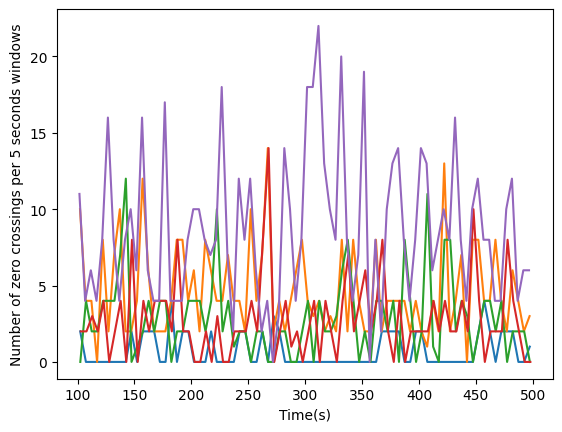

In [3]:
# plot number of zero crossing on a graph
for i in range(20, 25):
    file_name = f"{src_path}/result-clientServerRouter-{i}/zeroCrossingTrace-dumbbell.txt"

    # read it
    times, zc_list = [], []

    # Read cumulative packets with timestamps
    with open(file_name, "r") as f:
        for line in f:
            t, zc = line.strip().split()
            if(float(t) < 100):
                continue
            times.append(float(t))
            zc_list.append(int(zc))
    plt.xlabel("Time(s)")
    plt.ylabel("Number of zero crossings per 5 seconds windows")
    plt.plot(times, zc_list)

## False Positive Analysis
Simulation Details: 0 to 49= no congestion, 50 to 89 congestion should be there  
From 50-89 I have simulated 51 to 60 nodes scenario with different random seed  

1. From Simulation we know that if number of nodes less than 50 no congestion should be there
2. Actual Number where there is congestion = 40

In [4]:
# Calculate if three consecutive number of zero crossings less than threshold(5)
congZeroCrossings = 0
zero_crossing_threshold = 5
for i in range(0, 90):
    file_name = f"{src_path}/result-clientServerRouter-{i}/zeroCrossingTrace-dumbbell.txt"

    # read it
    times, zc_list = [], []

    # Read cumulative packets with timestamps
    with open(file_name, "r") as f:
        for line in f:
            t, zc = line.strip().split()
            if(float(t) < 100):
                continue
            times.append(float(t))
            zc_list.append(int(zc))
    cong = 0;
    for j in range(2, len(zc_list)):
        if(zc_list[j] < 5 and zc_list[j-1] < 5 and zc_list[j-2] < 5 and (zc_list[j] != 0 or zc_list[j-1] != 0 or zc_list[j-2] != 0)):
            cong=1
            # print(f"file: {file_name}, zc:{zc_list[j]}, {zc_list[j-1]}, {zc_list[j-2]}, time: {times[j]}")
            break
    if(cong == 1):
        congZeroCrossings+=1
print(f"Zero crossings: {congZeroCrossings}/90")

Zero crossings: 57/90


In [5]:
# Calculate using if queue size > 2000
congQsize = 0
qSizeThre = 2000
for i in range(0, 90):
    file_name = f"{src_path}/result-clientServerRouter-{i}/tc-qsizeTrace-dumbbell.txt"

    # read it
    times, qsize = [], []

    # Read cumulative packets with timestamps
    with open(file_name, "r") as f:
        for line in f:
            t, q = line.strip().split()
            if(float(t) < 100):
                continue
            times.append(float(t))
            qsize.append(int(q))
    cong = 0;
    for j in range(len(qsize)):
        if(qsize[j] > qSizeThre):
            cong=1
            # print(f"file: {file_name}, qsize: {qsize[j]}, time: {times[j]}")
            break
            
    if(cong == 1):
        congQsize+=1
print(f"Congestion: {congQsize}/90")

Congestion: 40/90


# ROC Curve Analysis


In [6]:
from sklearn.metrics import confusion_matrix

ERROR! Session/line number was not unique in database. History logging moved to new session 13


In [7]:
def calc_zc(simNum, winSize):
    file_name = f"{src_path}/result-clientServerRouter-{simNum}/tc-qsizeTrace-dumbbell.txt"
    t, x = [], []

    # Read cumulative packets with timestamps
    with open(file_name, "r") as f:
        for line in f:
            tt, q = line.strip().split()
            t.append(float(tt))
            x.append(int(q))

    t = np.array(t)
    x = np.array(x)

    # Determine sampling interval
    dt = np.median(np.diff(t))
    samples_per_window = int(winSize / dt)

    def autocorr(v):
        v = v - v.mean()
        n = len(v)
        ac = np.correlate(v, v, mode="full")
        ac = ac[n-1:] / ac[n-1]  # normalize
        return ac

    # zero-crossing detection
    def zero_crossings(signal):
        s = np.asarray(signal)
        return np.where(np.diff(np.signbit(s)))[0]

    N = len(x)
    out_times = []
    out_zc_counts = []

    # Sliding window
    for start in range(0, N - samples_per_window + 1):
        window = x[start:start + samples_per_window]

        ac = autocorr(window)
        zc_indices = zero_crossings(ac)
        zc_count = len(zc_indices)

        end_time = t[start + samples_per_window - 1]

        out_times.append(end_time)
        out_zc_counts.append(zc_count)

    return np.array(out_times), np.array(out_zc_counts)

def isCongestion(zc_list, zcTh):
    # Check three consecutive windows with low zero-crossing count
    for j in range(2, len(zc_list)):
        if (
            zc_list[j] < zcTh and
            zc_list[j-1] < zcTh and
            zc_list[j-2] < zcTh and
            (zc_list[j] > 0 or zc_list[j-1] > 0 or zc_list[j-2] > 0)
        ):
            return 1
    return 0

def tpr_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel() # calculate confusion matrix
    
    tpr = tp / (tp + fn)   # True Positive Rate (Recall)
    fpr = fp / (fp + tn)   # False Positive Rate
    
    return tpr, fpr

In [8]:
# first fifity: NO Congestion, next 50: Congestion
y_truth = np.zeros(100)
y_truth[50:] = 1
total_samples = 100
winSizes = [5, 10, 15, 20]
# no need for time data, just zero crossings

zc_data = {}
for ws in winSizes:
    zc_data[ws] = []
    for simNum in range(0, 100):
        _, zc_list = calc_zc(simNum, ws)
        zc_data[ws].append(zc_list)

/tmp/ipykernel_11567/3498124481.py:23: RuntimeWarning: invalid value encountered in divide
  ac = ac[n-1:] / ac[n-1]  # normalize


len(fpr): 29, len(tpr): 29, winSize: 5s
winSize: 5s
FPR:  [np.float64(0.0), np.float64(0.38), np.float64(0.42), np.float64(0.42), np.float64(0.42), np.float64(0.46), np.float64(0.46), np.float64(0.48), np.float64(0.48), np.float64(0.5), np.float64(0.58), np.float64(0.58), np.float64(0.64), np.float64(0.66), np.float64(0.7), np.float64(0.72), np.float64(0.72), np.float64(0.74), np.float64(0.78), np.float64(0.78), np.float64(0.78), np.float64(0.78), np.float64(0.78), np.float64(0.78), np.float64(0.78), np.float64(0.78), np.float64(0.78), np.float64(0.78), np.float64(0.78)]
TPR: [np.float64(0.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float

Text(0.5, 0, 'False Positive Rate')

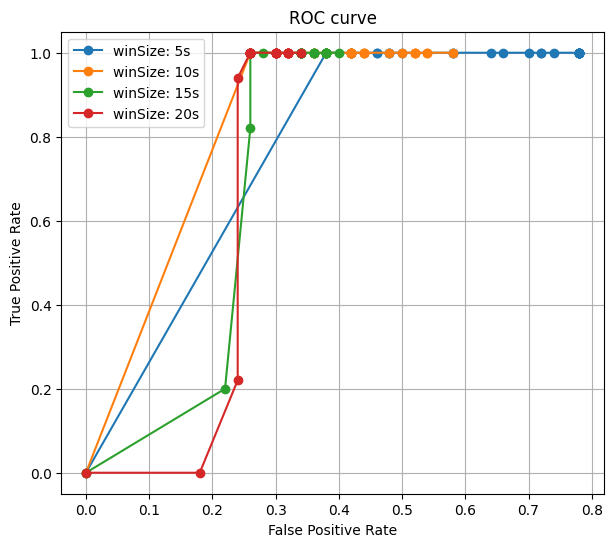

In [12]:
plt.figure(figsize=(7, 6))
results = []
for winSize in winSizes:
    tpr = []
    fpr = []
    for th in range(1, 30):
        y_pred = [isCongestion(zc_data[winSize][i], th)
                  for i in range(total_samples)]
        t_tpr, t_fpr = tpr_fpr(y_truth, y_pred)
        results.append([winSize, th, t_fpr, t_tpr])
        tpr.append(t_tpr)
        fpr.append(t_fpr)
    print(f"len(fpr): {len(fpr)}, len(tpr): {len(tpr)}, winSize: {winSize}s")
    print(f"winSize: {winSize}s")
    print("FPR: ", fpr)
    print("TPR:", tpr)
    print("******************************")
    plt.plot(fpr, tpr, marker='o', label=f"winSize: {winSize}s")

with open("roc_analysis_data.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["winSize", "ZC_Threshold", "FPR", "TPR"])
    writer.writerows(results)
    
plt.legend()
plt.grid()
plt.title("ROC curve")
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
